<a href="https://colab.research.google.com/github/Bhavya1130/Sales-Analysis/blob/main/ColabNotebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

In [49]:
FILE_PATH = "AusApparalSales4thQrt2020.csv"

df = pd.read_csv(FILE_PATH)

print("Dataset Shape:", df.shape)
display(df.head())
display(df.info())

Dataset Shape: (7560, 6)


,Date,Time,State,Group,Unit,Sales
0,1-Oct-2020,Morning,WA,Kids,8,20000
1,1-Oct-2020,Morning,WA,Men,8,20000
2,1-Oct-2020,Morning,WA,Women,4,10000
3,1-Oct-2020,Morning,WA,Seniors,15,37500
4,1-Oct-2020,Afternoon,WA,Kids,3,7500


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7560 entries, 0 to 7559
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    7560 non-null   object
 1   Time    7560 non-null   object
 2   State   7560 non-null   object
 3   Group   7560 non-null   object
 4   Unit    7560 non-null   int64 
 5   Sales   7560 non-null   int64 
dtypes: int64(2), object(4)
memory usage: 354.5+ KB


None

In [50]:
print("\nColumn Names:")
print(df.columns.tolist())

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print("\nMissing Values:")
print(df.isna().sum())

print("\nNon-Missing Values:")
print(df.notna().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

df = df.drop_duplicates()

# Convert data types
if "date" in df.columns:
    df["date"] = pd.to_datetime(df["date"], errors="coerce")

if "sales" in df.columns:
    df["sales"] = pd.to_numeric(df["sales"], errors="coerce")

if "unit" in df.columns:
    df["unit"] = pd.to_numeric(df["unit"], errors="coerce")

# Remove missing values from important columns
df = df.dropna(subset=["date", "sales", "unit"])

# Check incorrect values
print("\nNegative Sales:", (df["sales"] < 0).sum())
print("Negative Units:", (df["unit"] < 0).sum())

# Remove invalid values
df = df[(df["sales"] >= 0) & (df["unit"] >= 0)]

print("\nFinal Dataset Shape:", df.shape)


Column Names:
['Date', 'Time', 'State', 'Group', 'Unit', 'Sales']

Missing Values:
date     0
time     0
state    0
group    0
unit     0
sales    0
dtype: int64

Non-Missing Values:
date     7560
time     7560
state    7560
group    7560
unit     7560
sales    7560
dtype: int64

Duplicate Rows: 0

Negative Sales: 0
Negative Units: 0

Final Dataset Shape: (7560, 6)


In [51]:
scaler = MinMaxScaler()

df[["sales_normalized", "unit_normalized"]] = scaler.fit_transform(
    df[["sales", "unit"]]
)

display(df.head())

,date,time,state,group,unit,sales,sales_normalized,unit_normalized
0,2020-10-01,Morning,WA,Kids,8,20000,0.095238,0.095238
1,2020-10-01,Morning,WA,Men,8,20000,0.095238,0.095238
2,2020-10-01,Morning,WA,Women,4,10000,0.031746,0.031746
3,2020-10-01,Morning,WA,Seniors,15,37500,0.206349,0.206349
4,2020-10-01,Afternoon,WA,Kids,3,7500,0.015873,0.015873


In [52]:
print("\nSales Statistics:")
display(df["sales"].describe())

print("\nUnit Statistics:")
display(df["unit"].describe())

print("\nSales Mean:", df["sales"].mean())
print("Sales Median:", df["sales"].median())
print("Sales Mode:", df["sales"].mode().tolist())
print("Sales Standard Deviation:", df["sales"].std())

print("\nUnit Mean:", df["unit"].mean())
print("Unit Median:", df["unit"].median())
print("Unit Mode:", df["unit"].mode().tolist())
print("Unit Standard Deviation:", df["unit"].std())


Sales Statistics:


,sales
count,7560.000000
mean,45013.558201
std,32253.506944
min,5000.000000
25%,20000.000000
50%,35000.000000
75%,65000.000000
max,162500.000000



Unit Statistics:


,unit
count,7560.000000
mean,18.005423
std,12.901403
min,2.000000
25%,8.000000
50%,14.000000
75%,26.000000
max,65.000000



Sales Mean: 45013.5582010582
Sales Median: 35000.0
Sales Mode: [22500]
Sales Standard Deviation: 32253.506943966317

Unit Mean: 18.00542328042328
Unit Median: 14.0
Unit Mode: [9]
Unit Standard Deviation: 12.901402777586458


In [53]:
group_sales = (
    df.groupby("group")["sales"]
    .sum()
    .sort_values(ascending=False)
)

group_units = (
    df.groupby("group")["unit"]
    .sum()
    .sort_values(ascending=False)
)

print("\nGroup-wise Sales:")
display(group_sales)

print("\nGroup-wise Units:")
display(group_units)

highest_group = group_sales.idxmax()
lowest_group = group_sales.idxmin()

print("Highest Sales Group:", highest_group)
print("Lowest Sales Group:", lowest_group)


Group-wise Sales:


,sales
group,
Men,85750000
Women,85442500
Kids,85072500
Seniors,84037500



Group-wise Units:


,unit
group,
Men,34300
Women,34177
Kids,34029
Seniors,33615


Highest Sales Group:  Men
Lowest Sales Group:  Seniors


In [54]:
state_sales = (
    df.groupby("state")["sales"]
    .sum()
    .sort_values(ascending=False)
)

state_units = (
    df.groupby("state")["unit"]
    .sum()
    .sort_values(ascending=False)
)

print("\nState-wise Sales:")
display(state_sales)

print("\nState-wise Units:")
display(state_units)

highest_state = state_sales.idxmax()
lowest_state = state_sales.idxmin()

print("Highest Sales State:", highest_state)
print("Lowest Sales State:", lowest_state)


State-wise Sales:


,sales
state,
VIC,105565000
NSW,74970000
SA,58857500
QLD,33417500
TAS,22760000
NT,22580000
WA,22152500



State-wise Units:


,unit
state,
VIC,42226
NSW,29988
SA,23543
QLD,13367
TAS,9104
NT,9032
WA,8861


Highest Sales State:  VIC
Lowest Sales State:  WA


In [55]:
state_group_sales = (
    df.groupby(["state", "group"])["sales"]
    .sum()
    .reset_index()
)

state_group_pivot = pd.pivot_table(
    df,
    values="sales",
    index="state",
    columns="group",
    aggfunc="sum"
)

print("\nState and Group Sales:")
display(state_group_sales)

print("\nState × Group Sales:")
display(state_group_pivot)


State and Group Sales:


,state,group,sales
0,NSW,Kids,18587500
1,NSW,Men,19022500
2,NSW,Seniors,18187500
3,NSW,Women,19172500
4,NT,Kids,5700000
5,NT,Men,5762500
6,NT,Seniors,5465000
7,NT,Women,5652500
8,QLD,Kids,8510000
9,QLD,Men,8392500



State × Group Sales:


group,Kids,Men,Seniors,Women
state,,,,
NSW,18587500,19022500,18187500,19172500
NT,5700000,5762500,5465000,5652500
QLD,8510000,8392500,8190000,8325000
SA,14515000,14655000,14717500,14970000
TAS,5775000,5757500,5650000,5577500
VIC,26360000,26407500,26315000,26482500
WA,5625000,5752500,5512500,5262500


In [56]:
df["day"] = df["date"].dt.day
df["day_name"] = df["date"].dt.day_name()
df["week"] = df["date"].dt.isocalendar().week.astype(int)
df["month"] = df["date"].dt.month
df["month_name"] = df["date"].dt.month_name()
df["quarter"] = df["date"].dt.quarter
print(df.head())

        date        time state     group  unit  sales  sales_normalized  \
0 2020-10-01     Morning    WA      Kids     8  20000          0.095238   
1 2020-10-01     Morning    WA       Men     8  20000          0.095238   
2 2020-10-01     Morning    WA     Women     4  10000          0.031746   
3 2020-10-01     Morning    WA   Seniors    15  37500          0.206349   
4 2020-10-01   Afternoon    WA      Kids     3   7500          0.015873   

   unit_normalized  day  day_name  week  month month_name  quarter  
0         0.095238    1  Thursday    40     10    October        4  
1         0.095238    1  Thursday    40     10    October        4  
2         0.031746    1  Thursday    40     10    October        4  
3         0.206349    1  Thursday    40     10    October        4  
4         0.015873    1  Thursday    40     10    October        4  


In [57]:
print(df.head())

        date        time state     group  unit  sales  sales_normalized  \
0 2020-10-01     Morning    WA      Kids     8  20000          0.095238   
1 2020-10-01     Morning    WA       Men     8  20000          0.095238   
2 2020-10-01     Morning    WA     Women     4  10000          0.031746   
3 2020-10-01     Morning    WA   Seniors    15  37500          0.206349   
4 2020-10-01   Afternoon    WA      Kids     3   7500          0.015873   

   unit_normalized  day  day_name  week  month month_name  quarter  
0         0.095238    1  Thursday    40     10    October        4  
1         0.095238    1  Thursday    40     10    October        4  
2         0.031746    1  Thursday    40     10    October        4  
3         0.206349    1  Thursday    40     10    October        4  
4         0.015873    1  Thursday    40     10    October        4  


In [58]:
daily_report = (
    df.groupby("date")
    .agg(
        sales=("sales", "sum"),
        units=("unit", "sum")
    )
    .reset_index()
)

print("\nDaily Report:")
display(daily_report)


Daily Report:


,date,sales,units
0,2020-10-01,3720000,1488
1,2020-10-02,3715000,1486
2,2020-10-03,3890000,1556
3,2020-10-04,3720000,1488
4,2020-10-05,3862500,1545
...,...,...,...
85,2020-12-26,4715000,1886
86,2020-12-27,4637500,1855
87,2020-12-28,4595000,1838
88,2020-12-29,4607500,1843


In [59]:
print(df.head())

        date        time state     group  unit  sales  sales_normalized  \
0 2020-10-01     Morning    WA      Kids     8  20000          0.095238   
1 2020-10-01     Morning    WA       Men     8  20000          0.095238   
2 2020-10-01     Morning    WA     Women     4  10000          0.031746   
3 2020-10-01     Morning    WA   Seniors    15  37500          0.206349   
4 2020-10-01   Afternoon    WA      Kids     3   7500          0.015873   

   unit_normalized  day  day_name  week  month month_name  quarter  
0         0.095238    1  Thursday    40     10    October        4  
1         0.095238    1  Thursday    40     10    October        4  
2         0.031746    1  Thursday    40     10    October        4  
3         0.206349    1  Thursday    40     10    October        4  
4         0.015873    1  Thursday    40     10    October        4  


In [60]:
weekly_report = (
    df.groupby("week")
    .agg(
        sales=("sales", "sum"),
        units=("unit", "sum")
    )
    .reset_index()
)

print("\nWeekly Report:")
display(weekly_report)


Weekly Report:


,week,sales,units
0,40,15045000,6018
1,41,27002500,10801
2,42,26640000,10656
3,43,26815000,10726
4,44,21807500,8723
5,45,20865000,8346
6,46,21172500,8469
7,47,21112500,8445
8,48,21477500,8591
9,49,29622500,11849


In [61]:
print(df.head())

        date        time state     group  unit  sales  sales_normalized  \
0 2020-10-01     Morning    WA      Kids     8  20000          0.095238   
1 2020-10-01     Morning    WA       Men     8  20000          0.095238   
2 2020-10-01     Morning    WA     Women     4  10000          0.031746   
3 2020-10-01     Morning    WA   Seniors    15  37500          0.206349   
4 2020-10-01   Afternoon    WA      Kids     3   7500          0.015873   

   unit_normalized  day  day_name  week  month month_name  quarter  
0         0.095238    1  Thursday    40     10    October        4  
1         0.095238    1  Thursday    40     10    October        4  
2         0.031746    1  Thursday    40     10    October        4  
3         0.206349    1  Thursday    40     10    October        4  
4         0.015873    1  Thursday    40     10    October        4  


In [62]:
monthly_report = (
    df.groupby(["month", "month_name"])
    .agg(
        sales=("sales", "sum"),
        units=("unit", "sum")
    )
    .reset_index()
    .sort_values("month")
)

print("\nMonthly Report:")
display(monthly_report)


Monthly Report:


,month,month_name,sales,units
0,10,October,114290000,45716
1,11,November,90682500,36273
2,12,December,135330000,54132


In [63]:
print(df.head())

        date        time state     group  unit  sales  sales_normalized  \
0 2020-10-01     Morning    WA      Kids     8  20000          0.095238   
1 2020-10-01     Morning    WA       Men     8  20000          0.095238   
2 2020-10-01     Morning    WA     Women     4  10000          0.031746   
3 2020-10-01     Morning    WA   Seniors    15  37500          0.206349   
4 2020-10-01   Afternoon    WA      Kids     3   7500          0.015873   

   unit_normalized  day  day_name  week  month month_name  quarter  
0         0.095238    1  Thursday    40     10    October        4  
1         0.095238    1  Thursday    40     10    October        4  
2         0.031746    1  Thursday    40     10    October        4  
3         0.206349    1  Thursday    40     10    October        4  
4         0.015873    1  Thursday    40     10    October        4  


In [64]:
quarterly_report = (
    df.groupby("quarter")
    .agg(
        sales=("sales", "sum"),
        units=("unit", "sum")
    )
    .reset_index()
)

print("\nQuarterly Report:")
display(quarterly_report)



Quarterly Report:


,quarter,sales,units
0,4,340302500,136121


In [65]:
print(df.head())

        date        time state     group  unit  sales  sales_normalized  \
0 2020-10-01     Morning    WA      Kids     8  20000          0.095238   
1 2020-10-01     Morning    WA       Men     8  20000          0.095238   
2 2020-10-01     Morning    WA     Women     4  10000          0.031746   
3 2020-10-01     Morning    WA   Seniors    15  37500          0.206349   
4 2020-10-01   Afternoon    WA      Kids     3   7500          0.015873   

   unit_normalized  day  day_name  week  month month_name  quarter  
0         0.095238    1  Thursday    40     10    October        4  
1         0.095238    1  Thursday    40     10    October        4  
2         0.031746    1  Thursday    40     10    October        4  
3         0.206349    1  Thursday    40     10    October        4  
4         0.015873    1  Thursday    40     10    October        4  


In [66]:
print(df['time'].unique())

[' Morning' ' Afternoon' ' Evening']


In [67]:
if "time" in df.columns:

    # Clean time values
    df["time"] = df["time"].astype(str).str.strip().str.title()

    time_sales = (
        df.groupby("time")["sales"]
        .sum()
        .sort_values(ascending=False)
    )

    print("\nTime-of-Day Sales:")
    display(time_sales)

    if not time_sales.empty:
        max_sales = time_sales.idxmax()
        min_sales = time_sales.idxmin()

        print("Highest Sales Time:", max_sales)
        print("Lowest Sales Time:", min_sales)

else:
    print("\nTime column not available in dataset.")


Time-of-Day Sales:


,sales
time,
Morning,114207500
Afternoon,114007500
Evening,112087500


Highest Sales Time: Morning
Lowest Sales Time: Evening


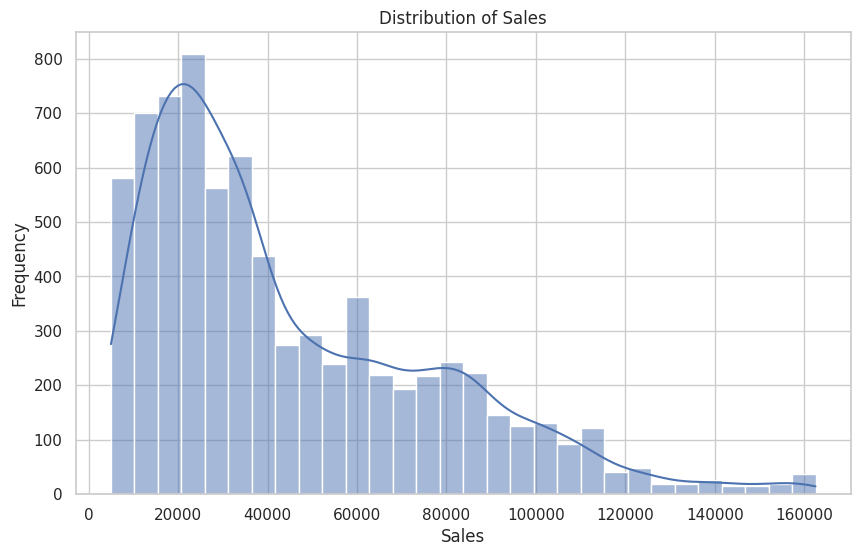

In [23]:
plt.figure(figsize=(10, 6))
sns.histplot(df["sales"], kde=True, bins=30)
plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

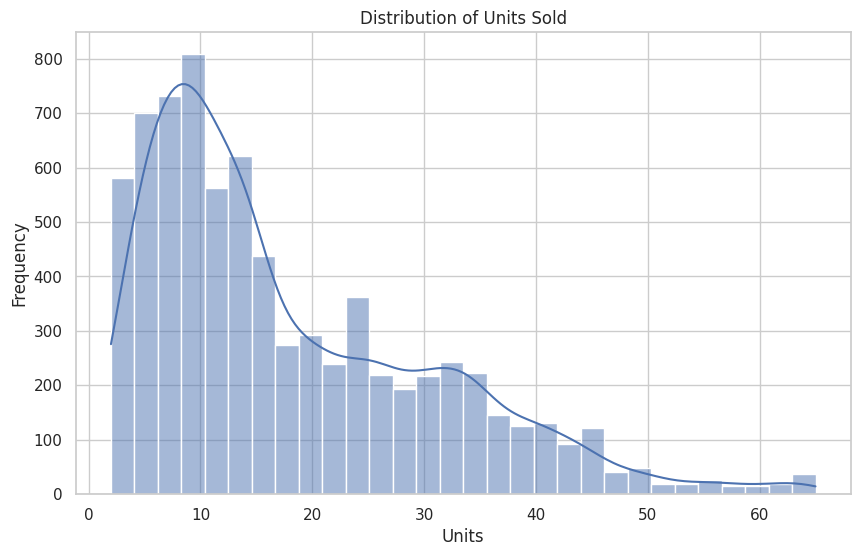

In [24]:
plt.figure(figsize=(10, 6))
sns.histplot(df["unit"], kde=True, bins=30)
plt.title("Distribution of Units Sold")
plt.xlabel("Units")
plt.ylabel("Frequency")
plt.show()

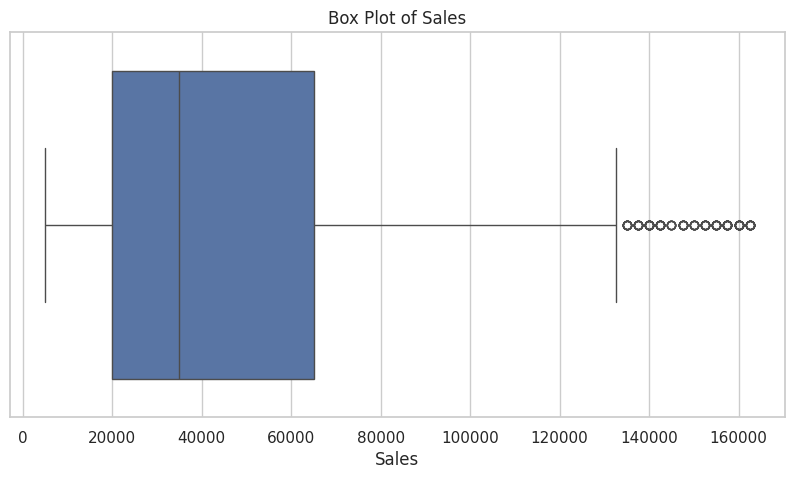

In [25]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=df["sales"])
plt.title("Box Plot of Sales")
plt.xlabel("Sales")
plt.show()

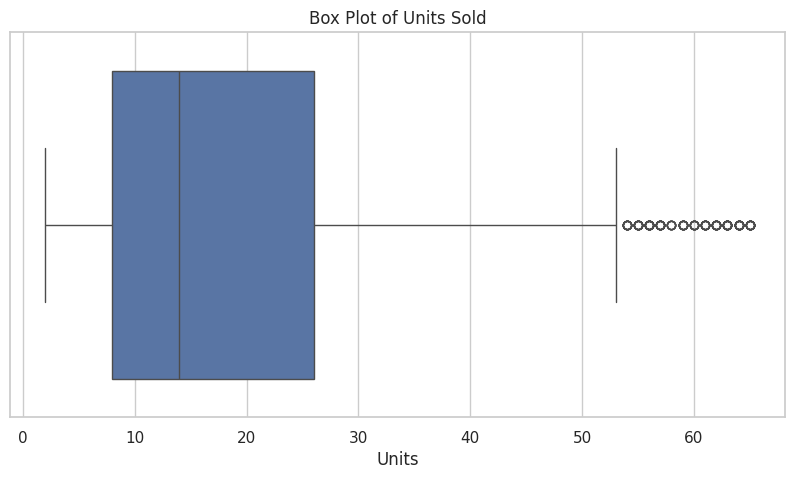

In [26]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=df["unit"])
plt.title("Box Plot of Units Sold")
plt.xlabel("Units")
plt.show()

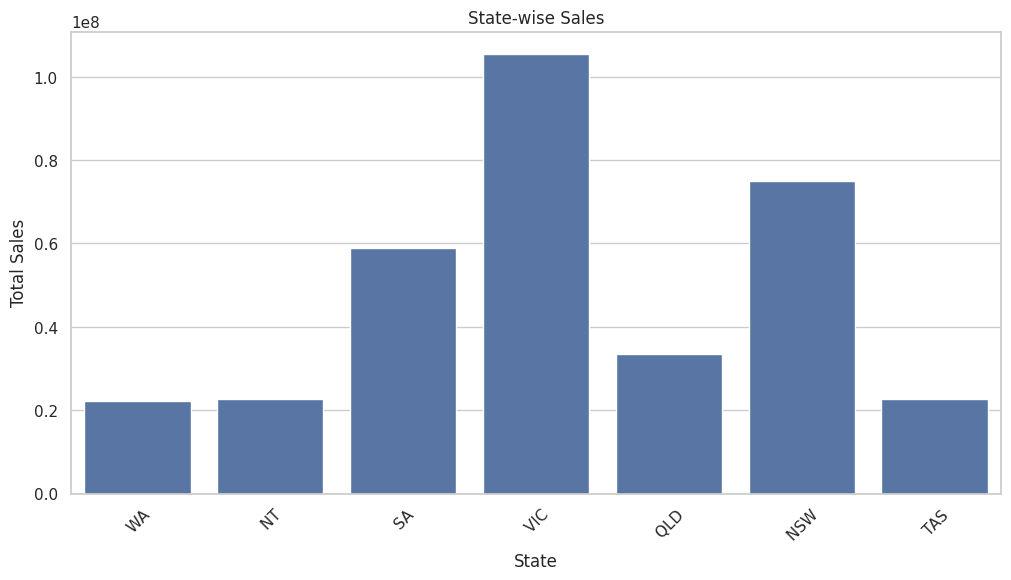

In [27]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=df,
    x="state",
    y="sales",
    estimator="sum",
    errorbar=None
)

plt.title("State-wise Sales")
plt.xlabel("State")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

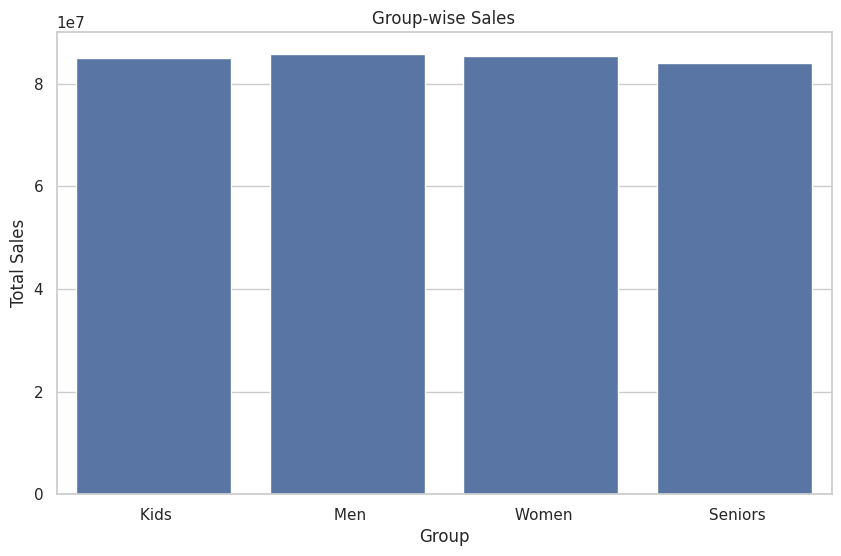

In [28]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df,
    x="group",
    y="sales",
    estimator="sum",
    errorbar=None
)

plt.title("Group-wise Sales")
plt.xlabel("Group")
plt.ylabel("Total Sales")
plt.show()

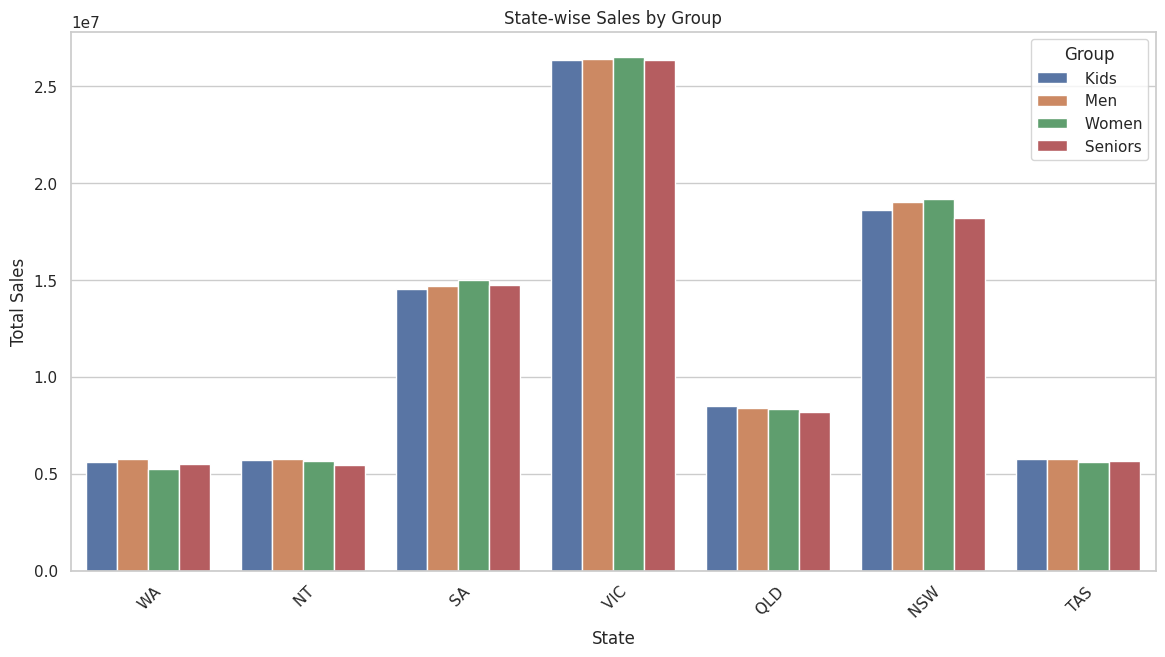

In [29]:
plt.figure(figsize=(14, 7))

sns.barplot(
    data=df,
    x="state",
    y="sales",
    hue="group",
    estimator="sum",
    errorbar=None
)

plt.title("State-wise Sales by Group")
plt.xlabel("State")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.legend(title="Group")
plt.show()

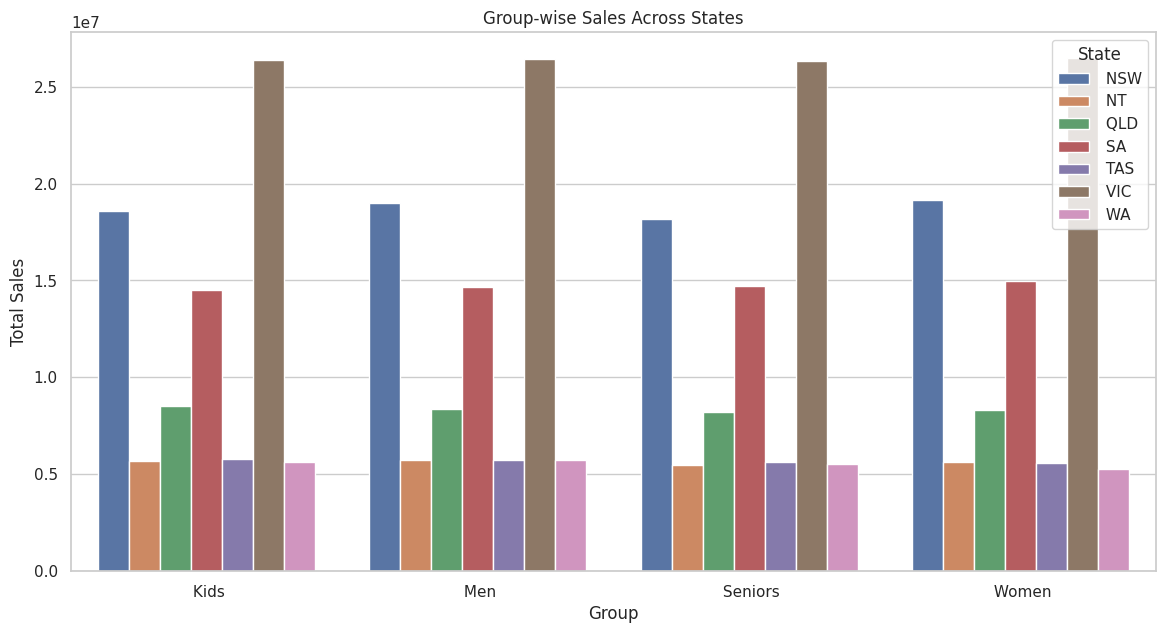

In [30]:
plt.figure(figsize=(14, 7))

sns.barplot(
    data=state_group_sales,
    x="group",
    y="sales",
    hue="state",
    errorbar=None
)

plt.title("Group-wise Sales Across States")
plt.xlabel("Group")
plt.ylabel("Total Sales")
plt.legend(title="State")
plt.show()

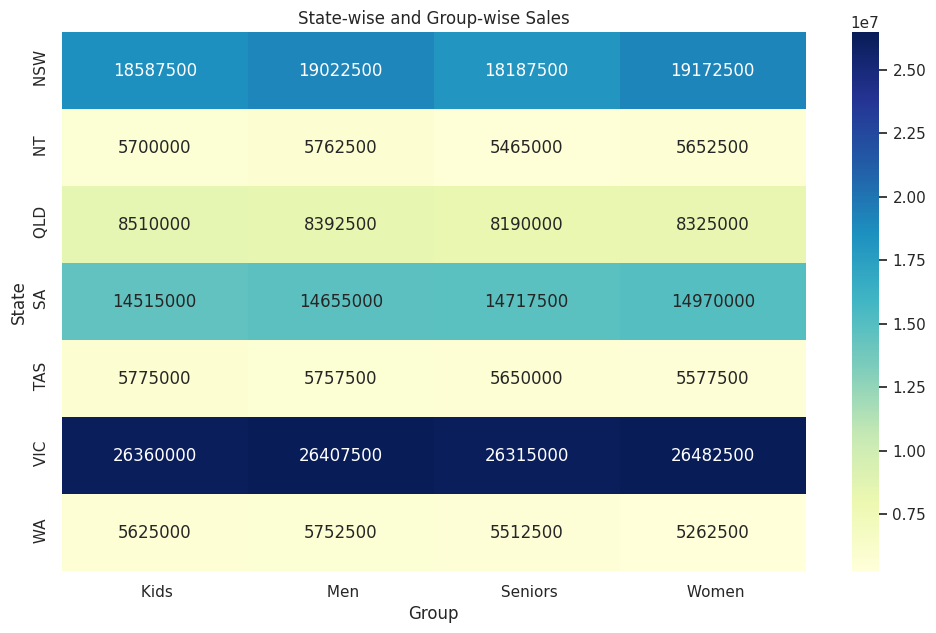

In [31]:
plt.figure(figsize=(12, 7))

sns.heatmap(
    state_group_pivot,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)

plt.title("State-wise and Group-wise Sales")
plt.xlabel("Group")
plt.ylabel("State")
plt.show()

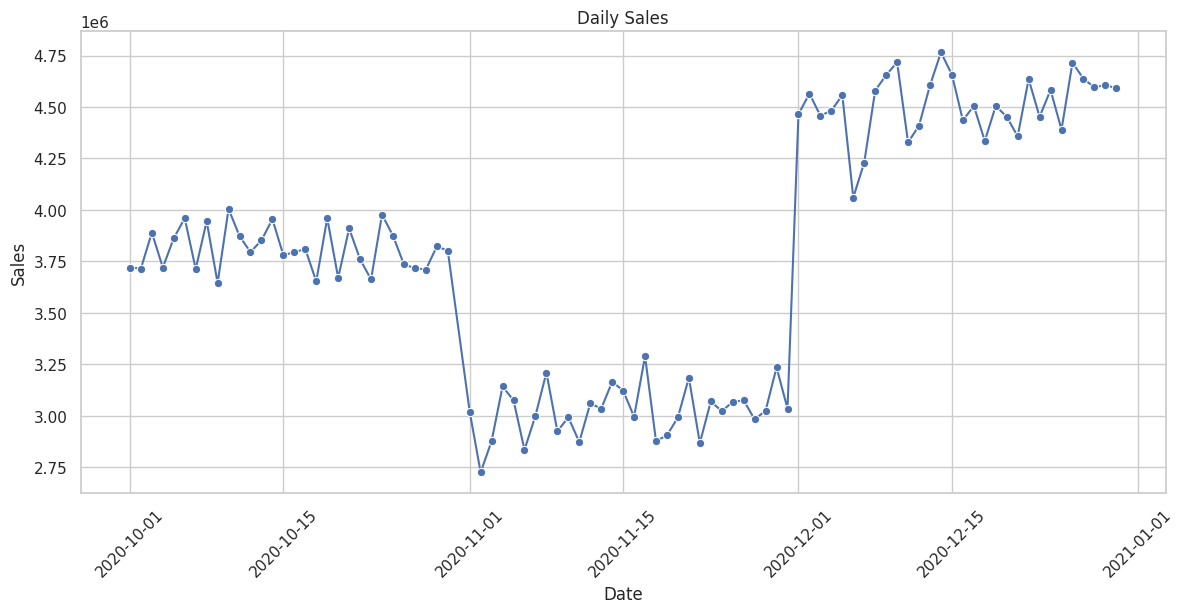

In [32]:
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=daily_report,
    x="date",
    y="sales",
    marker="o"
)

plt.title("Daily Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

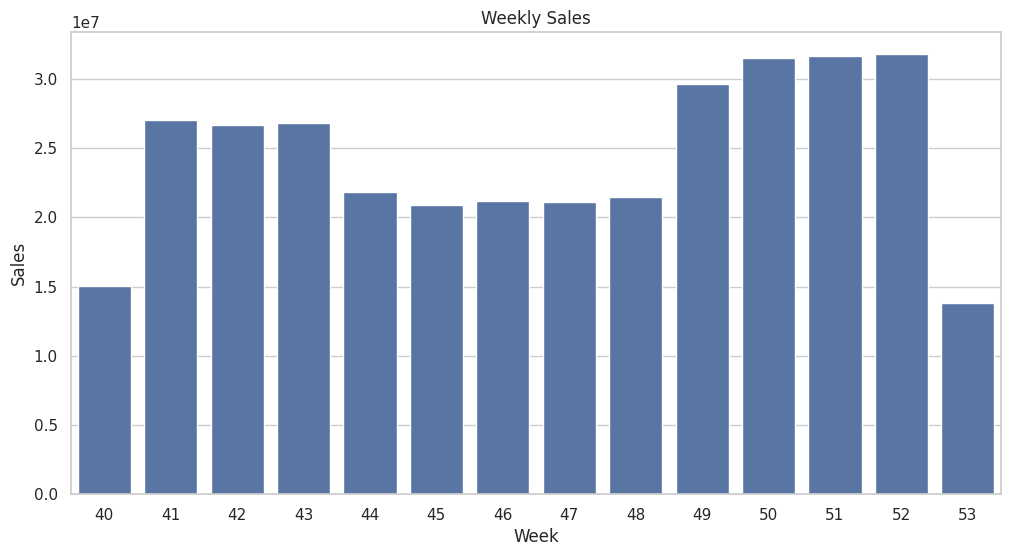

In [33]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=weekly_report,
    x="week",
    y="sales",
    errorbar=None
)

plt.title("Weekly Sales")
plt.xlabel("Week")
plt.ylabel("Sales")
plt.show()

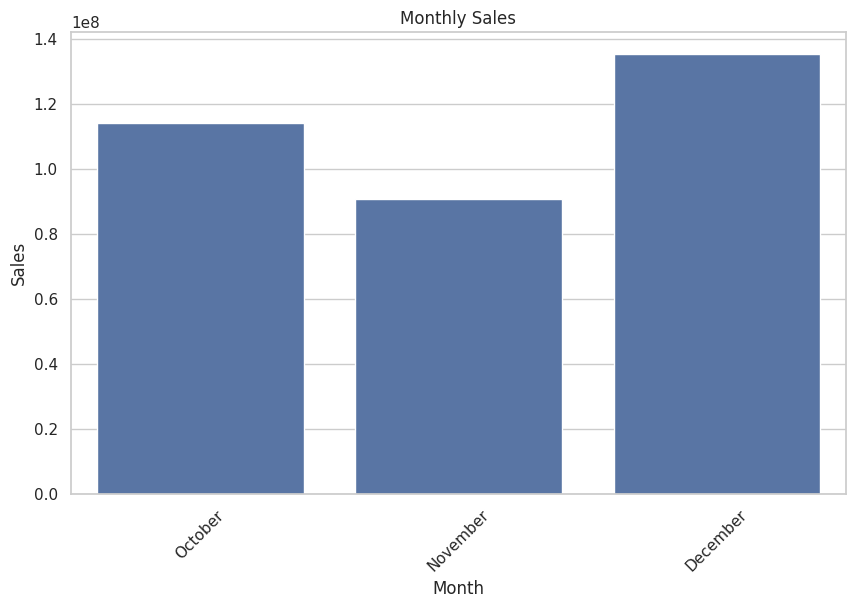

In [34]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=monthly_report,
    x="month_name",
    y="sales",
    errorbar=None
)

plt.title("Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

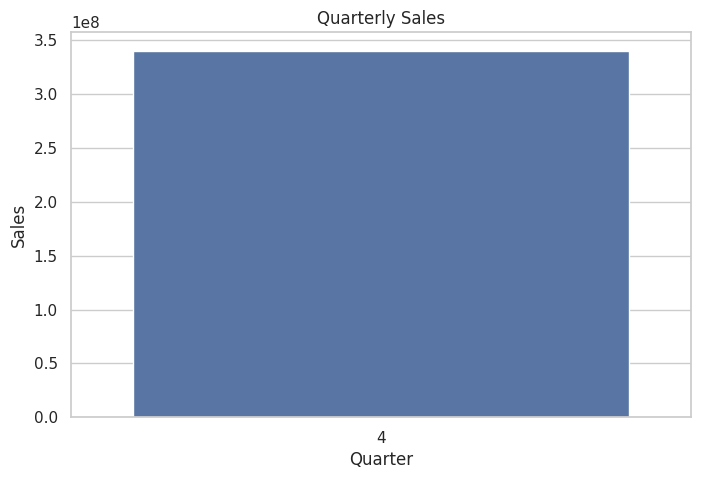

In [35]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=quarterly_report,
    x="quarter",
    y="sales",
    errorbar=None
)

plt.title("Quarterly Sales")
plt.xlabel("Quarter")
plt.ylabel("Sales")
plt.show()

In [68]:
if "hour" in df.columns:

    hourly_sales = (
        df.groupby("hour")["sales"]
        .sum()
        .reset_index()
    )

    plt.figure(figsize=(12, 6))

    sns.lineplot(
        data=hourly_sales,
        x="hour",
        y="sales",
        marker="o"
    )

    plt.title("Hourly Sales Analysis")
    plt.xlabel("Hour of Day")
    plt.ylabel("Sales")
    plt.xticks(range(24))
    plt.show()

In [69]:
if "time_period" in df.columns:

    order = ["Morning", "Afternoon", "Evening", "Night"]

    plt.figure(figsize=(10, 6))

    sns.barplot(
        data=df,
        x="time_period",
        y="sales",
        order=order,
        estimator="sum",
        errorbar=None
    )

    plt.title("Sales by Time of Day")
    plt.xlabel("Time of Day")
    plt.ylabel("Total Sales")
    plt.show()

In [38]:
state_sales_percentage = (
    state_sales / state_sales.sum() * 100
).round(2)

print("\nSales Percentage by State:")
display(state_sales_percentage)


Sales Percentage by State:


,sales
state,
VIC,31.02
NSW,22.03
SA,17.30
QLD,9.82
TAS,6.69
NT,6.64
WA,6.51


In [39]:
group_sales_percentage = (
    group_sales / group_sales.sum() * 100
).round(2)

print("\nSales Percentage by Group:")
display(group_sales_percentage)


Sales Percentage by Group:


,sales
group,
Men,25.20
Women,25.11
Kids,25.00
Seniors,24.69


In [40]:
print("\nTop 5 States:")
display(state_sales.head(5))

print("\nBottom 5 States:")
display(state_sales.tail(5))


Top 5 States:


,sales
state,
VIC,105565000
NSW,74970000
SA,58857500
QLD,33417500
TAS,22760000



Bottom 5 States:


,sales
state,
SA,58857500
QLD,33417500
TAS,22760000
NT,22580000
WA,22152500


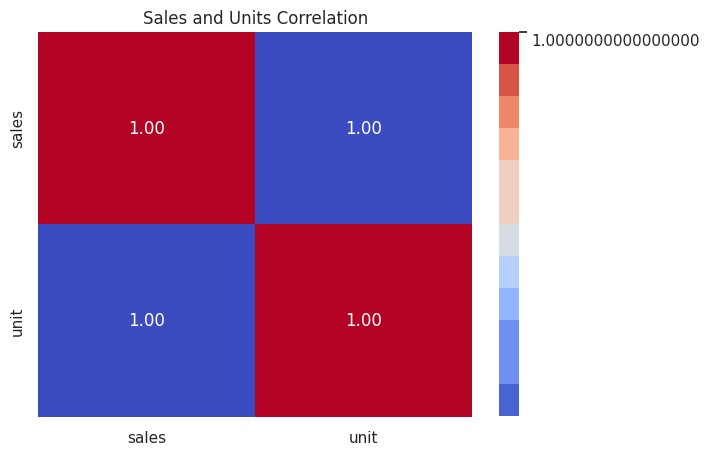

In [41]:
correlation = df[["sales", "unit"]].corr()

plt.figure(figsize=(7, 5))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Sales and Units Correlation")
plt.show()

In [43]:
print(df.head())

        date time state     group  unit  sales  sales_normalized  \
0 2020-10-01  NaT    WA      Kids     8  20000          0.095238   
1 2020-10-01  NaT    WA       Men     8  20000          0.095238   
2 2020-10-01  NaT    WA     Women     4  10000          0.031746   
3 2020-10-01  NaT    WA   Seniors    15  37500          0.206349   
4 2020-10-01  NaT    WA      Kids     3   7500          0.015873   

   unit_normalized  day  day_name  week  month month_name  quarter  hour  \
0         0.095238    1  Thursday    40     10    October        4   NaN   
1         0.095238    1  Thursday    40     10    October        4   NaN   
2         0.031746    1  Thursday    40     10    October        4   NaN   
3         0.206349    1  Thursday    40     10    October        4   NaN   
4         0.015873    1  Thursday    40     10    October        4   NaN   

   time_period  
0          NaN  
1          NaN  
2          NaN  
3          NaN  
4          NaN  


In [71]:
print("\n" + "=" * 60)
print("AAL SALES ANALYSIS - BUSINESS SUMMARY")
print("=" * 60)

print(f"\nHighest Revenue State : {highest_state}")
print(f"Lowest Revenue State  : {lowest_state}")

print(f"\nHighest Revenue Group : {highest_group}")
print(f"Lowest Revenue Group  : {lowest_group}")

if "time_period" in df.columns:
    print(f"\nHighest Sales Time     : {time_sales.idxmax()}")
    print(f"Lowest Sales Time      : {time_sales.idxmin()}")

print("\nTop 5 States by Revenue:")
display(state_sales.head(5))

print("\nBottom 5 States by Revenue:")
display(state_sales.tail(5))

print("\nGroup-wise Revenue:")
display(group_sales)


AAL SALES ANALYSIS - BUSINESS SUMMARY

Highest Revenue State :  VIC
Lowest Revenue State  :  WA

Highest Revenue Group :  Men
Lowest Revenue Group  :  Seniors

Top 5 States by Revenue:


,sales
state,
VIC,105565000
NSW,74970000
SA,58857500
QLD,33417500
TAS,22760000



Bottom 5 States by Revenue:


,sales
state,
SA,58857500
QLD,33417500
TAS,22760000
NT,22580000
WA,22152500



Group-wise Revenue:


,sales
group,
Men,85750000
Women,85442500
Kids,85072500
Seniors,84037500
